# 06 - DINOv2 Embedding Analizi

Bu notebook içerisinde bir önceki aşamada DINOv2 modeli kullanılarak oluşturulan embeddingler analiz edilmektedir.

Embeddingler, her görüntünün görsel içeriğini temsil eden yüksek boyutlu özellik vektörleridir.

Bu notebookun amacı;

- oluşturulan embeddingleri yüklemek,
- metadata ile eşleştirmek,
- PCA (Principal Component Analysis) yöntemi ile boyut indirgeme yapmak,
- görseller arasındaki benzerlikleri incelemek,
- veri setinin görsel dağılımını analiz etmektir.

Bu analiz sayesinde veri setindeki temaların birbirinden ne kadar ayrıştığı görsel olarak değerlendirilebilecektir.

# Gerekli Kütüphaneler

Bu bölümde embedding analizi için kullanılacak Python kütüphaneleri yüklenmektedir.

Kullanılacak temel araçlar:

- NumPy → embedding dosyalarını okumak
- Pandas → metadata işlemleri
- Matplotlib → grafik oluşturmak
- Scikit-Learn → PCA analizi

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# Embedding Dosyasının Yüklenmesi

Bir önceki notebookta oluşturulan DINOv2 embedding dosyası diske kaydedilmişti.

Bu bölümde bu dosya tekrar okunarak analiz için belleğe alınmaktadır.

In [2]:
embeddings = np.load("../embeddings/chrd_real_embeddings.npy")

print("Embedding Boyutu:", embeddings.shape)

Embedding Boyutu: (82, 768)


# Metadata Dosyasının Okunması

Embeddinglerin hangi görüntüye ve hangi temaya ait olduğunu belirlemek için metadata dosyası okunmaktadır.

Bu bilgiler daha sonra grafiklerin renklendirilmesinde kullanılacaktır.

In [3]:
df = pd.read_csv(
    "../data/CHRD_Real/metadata_selected.csv",
    sep=";"
)

# Embedding oluşturulan görsel sayısı kadar metadata kullan
df = df.iloc[:len(embeddings)].reset_index(drop=True)

print(df.shape)

(82, 11)


# Embedding ve Metadata Kontrolü

Embedding sayısı ile metadata içerisindeki görüntü sayısının aynı olması gerekmektedir.

Bu kontrol, veri bütünlüğünü doğrulamak amacıyla yapılmaktadır.

In [4]:
print("Metadata Görsel Sayısı :", len(df))

print("Embedding Sayısı :", len(embeddings))

Metadata Görsel Sayısı : 82
Embedding Sayısı : 82


# PCA (Principal Component Analysis)

DINOv2 tarafından üretilen embeddingler 768 boyutludur.

Bu kadar yüksek boyutlu verilerin doğrudan görselleştirilmesi mümkün değildir.

Bu nedenle PCA yöntemi kullanılarak embeddingler iki boyuta indirgenmektedir.

Böylece görseller arasındaki benzerlikler iki boyutlu bir düzlem üzerinde incelenebilir.

In [5]:
pca = PCA(n_components=2)

embedding_pca = pca.fit_transform(embeddings)

print(embedding_pca.shape)

(82, 2)


# PCA Sonuçlarının Görselleştirilmesi

Bu bölümde iki boyuta indirgenen embeddingler grafik üzerinde gösterilmektedir.

Grafikte;

- Her nokta bir görüntüyü temsil etmektedir.
- Noktaların birbirine yakın olması görsel benzerliğin yüksek olduğunu göstermektedir.
- Uzak noktalar ise görsel içerik açısından birbirinden farklı görüntüleri temsil etmektedir.

İlk görselleştirme herhangi bir tema ayrımı yapılmadan gerçekleştirilmektedir.

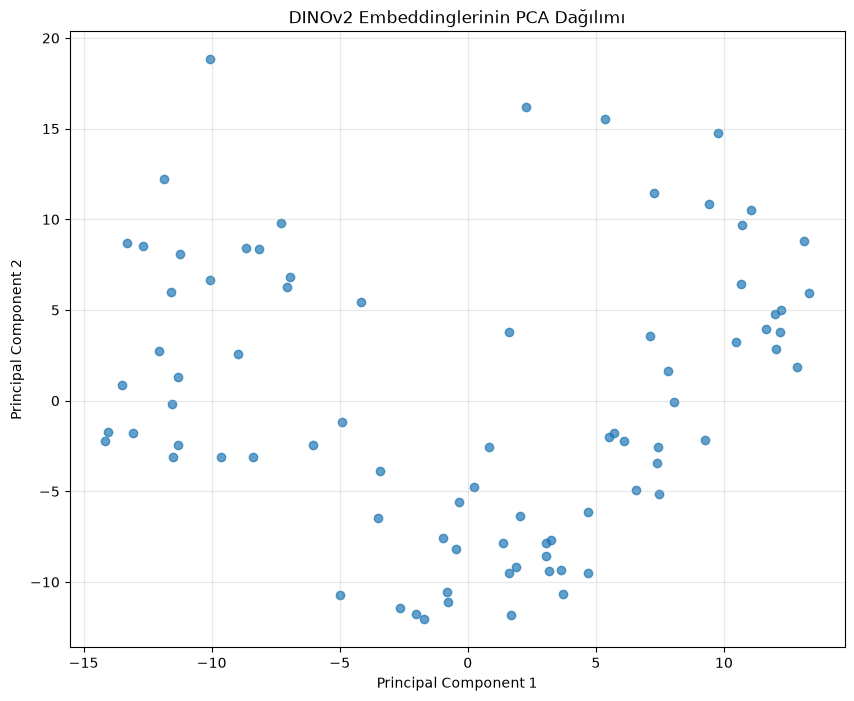

In [6]:
plt.figure(figsize=(10,8))

plt.scatter(
    embedding_pca[:,0],
    embedding_pca[:,1],
    alpha=0.7
)

plt.title("DINOv2 Embeddinglerinin PCA Dağılımı")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.show()

# Temalara Göre PCA Dağılımı

Bu bölümde aynı PCA sonuçları, görüntülerin ait olduğu temalara göre renklendirilmektedir.

Böylece aynı temaya ait görüntülerin birbirine yakın kümelenip kümelenmediği gözlemlenebilir.

Eğer aynı tema içerisindeki görüntüler benzer görsel özelliklere sahipse, aynı bölgelerde yoğunlaşmaları beklenmektedir.

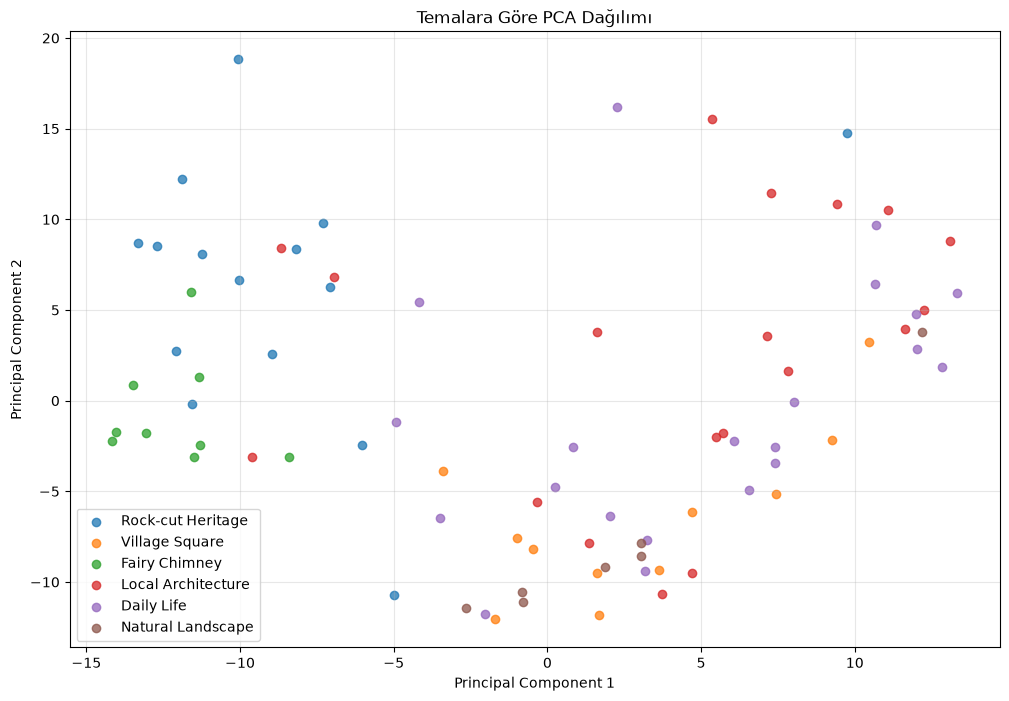

In [7]:
plt.figure(figsize=(12,8))

themes = df["theme"].unique()

for theme in themes:

    mask = df["theme"] == theme

    plt.scatter(
        embedding_pca[mask,0],
        embedding_pca[mask,1],
        label=theme,
        alpha=0.75
    )

plt.title("Temalara Göre PCA Dağılımı")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# PCA Sonuçlarının Sayısal Olarak Değerlendirilmesi

PCA analizi sonucunda ilk iki ana bileşenin veri setindeki toplam varyansın ne kadarını açıkladığı hesaplanmaktadır.

Bu değer, iki boyutlu görselleştirmenin veri setini ne ölçüde temsil ettiğini göstermektedir.

Açıklanan varyans oranı arttıkça PCA görselleştirmesinin veri yapısını temsil etme başarısı da artmaktadır.

In [8]:
print("1. Ana Bileşen :", round(pca.explained_variance_ratio_[0],4))

print("2. Ana Bileşen :", round(pca.explained_variance_ratio_[1],4))

print()

print("Toplam Açıklanan Varyans :",
      round(sum(pca.explained_variance_ratio_),4))

1. Ana Bileşen : 0.1658
2. Ana Bileşen : 0.1396

Toplam Açıklanan Varyans : 0.3054


# Tema Başına Görüntü Sayılarının Kontrolü

Bu bölümde embedding analizine dahil edilen veri kümesindeki tema dağılımı incelenmektedir.

Bu kontrol, PCA grafiğinde bazı temaların neden daha yoğun veya daha seyrek göründüğünü yorumlayabilmek açısından önemlidir.

In [9]:
df["theme"].value_counts()

theme
Daily Life            21
Local Architecture    19
Rock-cut Heritage     15
Village Square        11
Fairy Chimney          9
Natural Landscape      7
Name: count, dtype: int64

# Sonuç

Bu notebook içerisinde DINOv2 modeli ile oluşturulan embeddingler analiz edilmiştir.

Gerçekleştirilen işlemler:

- embedding dosyaları okunmuştur.
- metadata ile eşleştirme yapılmıştır.
- PCA yöntemi uygulanmıştır.
- iki boyutlu dağılım görselleştirilmiştir.
- temalara göre kümelenme incelenmiştir.

Bir sonraki notebookta bu embeddingler kullanılarak daha ayrıntılı benzerlik analizleri gerçekleştirilecektir.